In [1]:
from qiskit import __version__
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
import numpy as np

ket0 = np.array([[1],[0]])
ket1 = np.array([[0],[1]])
hdmrd = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]])
# print(1/np.sqrt(2)*hdmrd
# print(hdmrd @ ket0)
# (array_to_latex(hdmrd @ ket1))
# print(hdmrd)
# print(np.round(hdmrd @ hdmrd))
# u = Statevector([np.sqrt(3)/2, 1/2])
# display(u.draw("latex"))
# print(u.sample_counts(1000))
# plot_histogram(u.sample_counts(500))
# y = Operator([[0, -1.0j], [1.0j, 0]])
# display(y.draw("latex"))
# z = Statevector([[1],[0]])
# cv = z.evolve(y)
# display(cv.draw("latex"))

In [2]:
from qiskit.quantum_info import Statevector, Operator
import numpy as np
# x1 = Statevector.from_label("1")
# display(x1.draw("latex"))
# x2 = Statevector.from_label("01")
# display(x2.draw("latex"))
# zero = Statevector.from_label("0")
# one = Statevector.from_label("1")
# zo = zero.tensor(one)
# array_to_latex(zo)

# H = Operator.from_label("H")
# display(array_to_latex(H))
# X = Operator.from_label("X")
# array_to_latex(X)
# display(array_to_latex(H ^ X))

w = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / np.sqrt(3))
# w.draw("latex")
# display(w)
res, state = w.measure([0, 1])
# print(res)
# res, state = w.measure([0])
# display(state.draw("latex"))

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)
protocol.h(ebit0)
print(protocol)

          
  Q: ─────
     ┌───┐
  A: ┤ H ├
     └───┘
  B: ─────
          
a: 1/═════
          
b: 1/═════
          


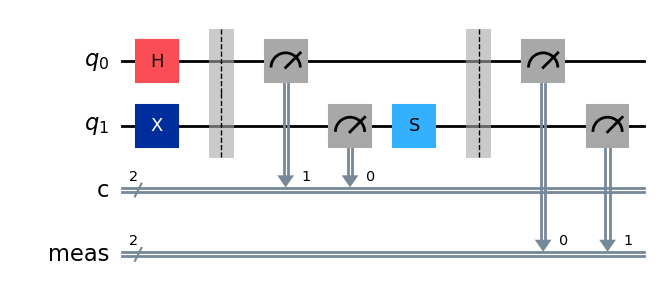

In [4]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.x(1)
qc.barrier()
qc.measure(0,1)
qc.measure(1,0)
qc.s(1)
qc.measure_all()
qc.draw(output="mpl")

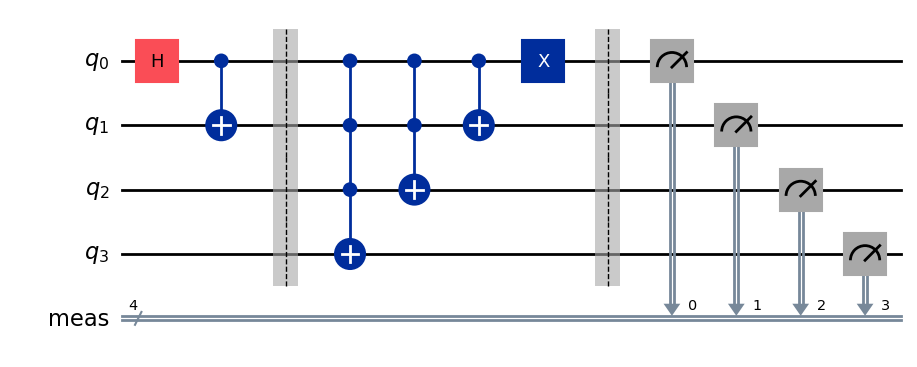

In [5]:
from qiskit.circuit.library.standard_gates import C3XGate
from qiskit_aer import Aer
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Initialize circuit as 0000 = 0
spi = QuantumCircuit(4)

spi.h(0)
spi.cx(0,1)

spi.barrier()
# Implement incrementor
spi.append(C3XGate(), [0,1,2,3])
spi.ccx(0,1,2)
spi.cx(0, 1)
spi.x(0)

# Measure
spi.measure_all()
spi.draw(output="mpl", style="iqp")

Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='2434e3b5-e554-496f-b946-b401a88911fa', success=True, results=[ExperimentResult(shots=5000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x4': 2525, '0x1': 2475}), header={'creg_sizes': [['meas', 4]], 'global_phase': 0.0, 'memory_slots': 4, 'n_qubits': 4, 'name': 'circuit-48', 'qreg_sizes': [['q', 4]], 'metadata': {}}, status=DONE, seed_simulator=3915448482, metadata={'batched_shots_optimization': False, 'required_memory_mb': 1, 'method': 'statevector', 'active_input_qubits': [0, 1, 2, 3], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 4, 'num_clbits': 4, 'time_taken': 0.0224173, 'sample_measure_time': 0.0057052, 'input_qubit_map': [[0, 0], [1, 1], [2, 2], [3, 3]], 'max_memory_mb': 16068, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 16, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': True, 'threshold': 14, 'max_fused

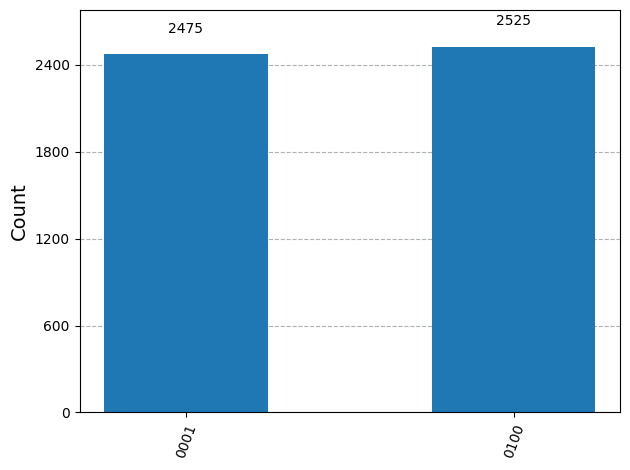

In [6]:
simulator = Aer.get_backend('aer_simulator')
result = simulator.run(spi, shots=5000).result()
print(result)
plot_histogram((result.get_counts()))

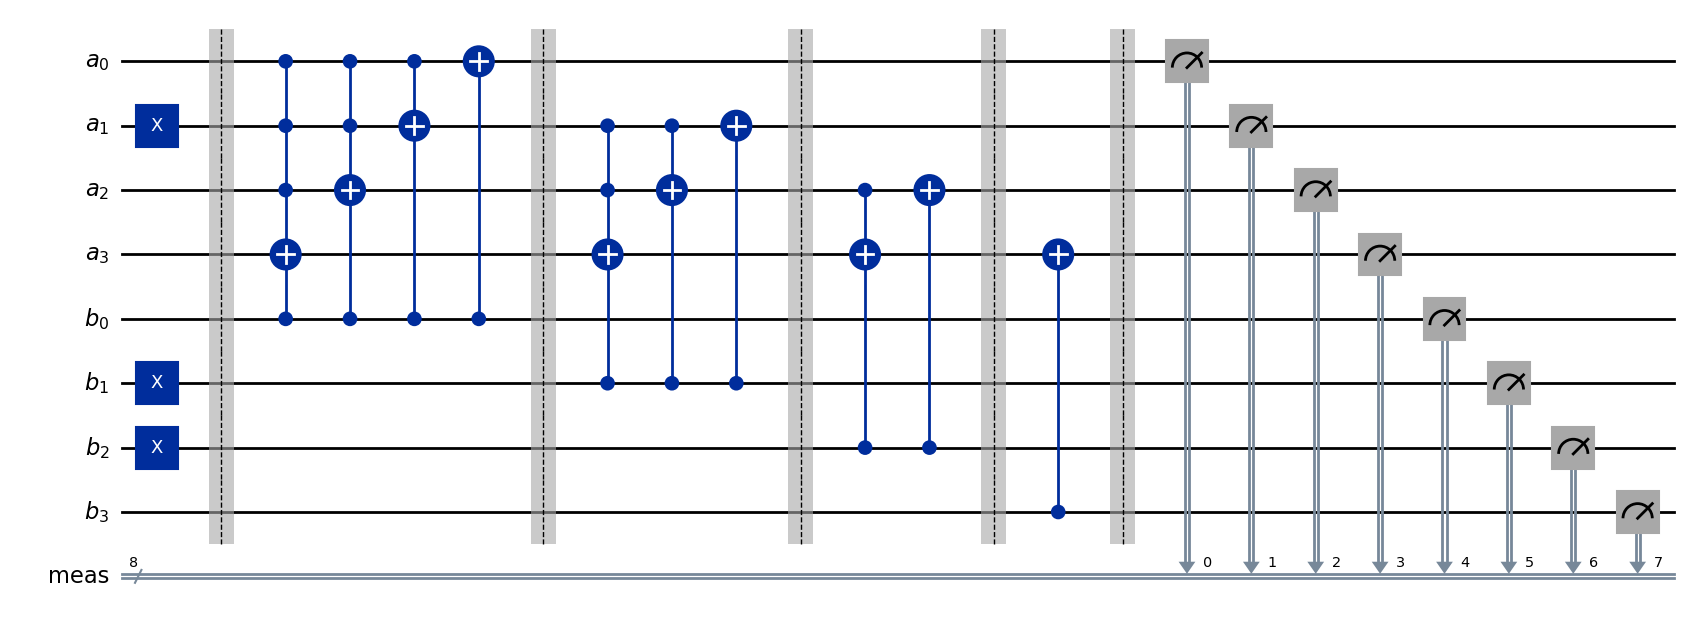

In [7]:
from qiskit import QuantumRegister
from qiskit.circuit.library.standard_gates import C4XGate, C3XGate

# prepare two numbers using a new feature "QuantumRegister"
a = QuantumRegister(4, name="a")
b = QuantumRegister(4, name="b")

adder = QuantumCircuit(a, b)

# set a to 0010 = 2
adder.x(a[1])
# set b to 0110 = 6
adder.x(b[1])
adder.x(b[2])

# implement the addition
adder.barrier()
adder.append(C4XGate(), [0, 1, 2, 4, 3])
adder.append(C3XGate(), [0, 1, 4, 2])
adder.ccx(0, 4, 1)
adder.cx(4, 0)

adder.barrier()
adder.append(C3XGate(), [1, 2, 5, 3])
adder.ccx(1, 5, 2)
adder.cx(5, 1)

adder.barrier()
adder.ccx(2,6,3)
adder.cx(6,2)

adder.barrier()
adder.cx(7,3)

adder.measure_all()
adder.draw(output="mpl", style="iqp")

Counts: {'0001': 100}


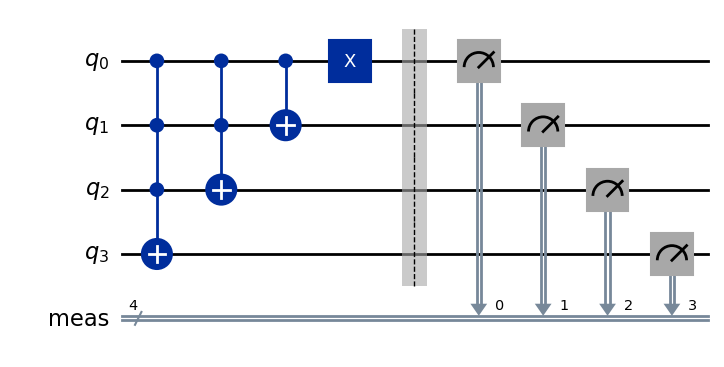

In [8]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import C3XGate
from qiskit_aer import AerSimulator

simulator = AerSimulator()

qc = QuantumCircuit(4)
qc.append(C3XGate(), [0, 1, 2, 3])
qc.ccx(0, 1, 2)
qc.cx(0, 1)
qc.x(0)


qc.measure_all()

res = simulator.run(qc, shots=100).result()
counts = res.get_counts()

print("Counts:", counts)

# Draw circuit
qc.draw(output="mpl")

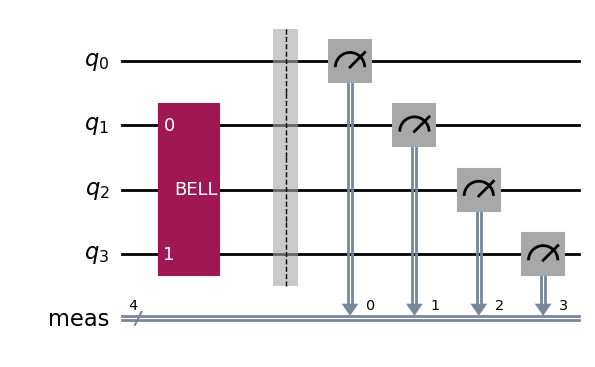

{'1010': 493, '0000': 507}


In [9]:
from qiskit import transpile
def entangle_two():
    qc = QuantumCircuit(2, name = "BELL")
    qc.h(0)
    qc.cx(0,1)
    # display(qc.draw(output="mpl"))
    return qc.to_gate()
entangle_two()
qc = QuantumCircuit(4)
qc.append(entangle_two(),[1,3])
qc.measure_all()
display(qc.draw(output="mpl"))
simulator = AerSimulator()
qc = transpile(qc, simulator)
op = simulator.run(qc, shots = 1000).result()
print(op.get_counts())

In [13]:
from qiskit import QuantumCircuit
qc1 = QuantumCircuit(2)
qc1.h(0);
qc1.cx(0, 1);
qc2 = QuantumCircuit(2)
qc2.x(0)
qc2.z(1)
combined = qc1.compose(qc2)
# combined1 = qc1.compose(qc2, inplace = True)
print(combined)
print(qc1)

     ┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ X ├
     └───┘┌─┴─┐├───┤
q_1: ─────┤ X ├┤ Z ├
          └───┘└───┘
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘


In [9]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.swap(0,1)
print(qc)
print(qc.decompose())

        
q_0: ─X─
      │ 
q_1: ─X─
        
          ┌───┐     
q_0: ──■──┤ X ├──■──
     ┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├──■──┤ X ├
     └───┘     └───┘
